In [1]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/population-of-pakistan-dataset/sub-division_population_of_pakistan.csv
/kaggle/input/pakistan-population-data-set/pakData.csv


# Pakistani Population Analysis

Author Name : **MD Rakib Hossen Howladar**\
Email : _howladarmdrakibhossen@gmail.com_\
GitHub Link : [RakibHossen490](https://github.com/RakibHossen490)

The Data is Collected From Following [Link](https://www.kaggle.com/datasets/mabdullahsajid/population-of-pakistan-dataset)\
#### **Years of Data**
1. 2017
2. 1998

## *The Data collected from the Source has following Description*
### Description
This dataset contains demographic information from the Pakistan Population Census conducted in 2017. It provides detailed population data at various administrative levels within Pakistan, including provinces, divisions, districts, and sub-divisions. The dataset also includes information on urban and rural populations, gender distribution, transgender individuals, sex ratios, population figures from the 1998 census, and annual growth rates.

#### Features
Province: The administrative provinces or regions of Pakistan where the census data was collected.

**Division**: The divisions within each province. Divisions are the second level of administrative divisions in Pakistan.

**District**: Districts within each division, representing larger administrative units.

**Sub-Division**: Sub-divisions or tehsils within each district, providing more localized data.

**Area**: The land area (in square kilometers) of each sub-division.

**_Urban Population 2017_**: The population of urban areas within each sub-division for the year 2017.

**_Rural Population 2017_**: The population of rural areas within each sub-division for the year 2017.

**_Male Population 2017_**: The male population within each sub-division for the year 2017.

**_Female Population 2017_**: The female population within each sub-division for the year 2017.

**_Transgender Population 2017_**: The population of transgender individuals within each sub-division for the year 2017.

**Sex Ratio 2017**: The sex ratio, calculated as the number of females per 1000 males, within each sub-division for the year 2017.

**Population in 1998**: The total population of each sub-division as recorded in the 1998 census.

**Annual Growth Rate**: The annual growth rate of the population in each sub-division, calculated as the percentage increase from 1998 to 2017.

`Data Source`
The data in this dataset was collected from official Pakistan Population Census reports and may include data from various government sources. It is essential to provide proper attribution and reference the original sources when using this dataset for analysis or research.

`Data Usage`
Researchers and analysts can use this dataset to explore demographic trends, population growth, urbanization rates, gender distribution, and more within Pakistan at different administrative levels. Ensure compliance with ethical and legal guidelines when using this data for research or public sharing.

Please note that this description is a template, and you should adapt it based on the actual data sources and specific details of your dataset when creating it for Kaggle or any other platform.




## Purpose Of Analysis The Data
The purpose of this analysis is to study the population trends of Pakistan over the years. This project explores growth patterns, distribution, and other demographic insights that can help understand social and economic changes

In [2]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Import the Dataset
df=pd.read_csv('/kaggle/input/pakistan-population-data-set/pakData.csv')

In [4]:
#Composition
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PROVINCE                    528 non-null    object 
 1   DIVISION                    528 non-null    object 
 2   DISTRICT                    528 non-null    object 
 3   SUB DIVISION                528 non-null    object 
 4   AREA (sq.km)                528 non-null    float64
 5   ALL SEXES (RURAL)           528 non-null    int64  
 6   MALE (RURAL)                528 non-null    int64  
 7   FEMALE (RURAL)              528 non-null    int64  
 8   TRANSGENDER (RURAL)         528 non-null    int64  
 9   SEX RATIO (RURAL)           528 non-null    float64
 10  AVG HOUSEHOLD SIZE (RURAL)  528 non-null    float64
 11  POPULATION 1998 (RURAL)     528 non-null    int64  
 12  ANNUAL GROWTH RATE (RURAL)  528 non-null    float64
 13  ALL SEXES (URBAN)           528 non

In [5]:
#Max Column Printing Option
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [6]:
df.head()

,PROVINCE,DIVISION,DISTRICT,SUB DIVISION,AREA (sq.km),ALL SEXES (RURAL),MALE (RURAL),FEMALE (RURAL),TRANSGENDER (RURAL),SEX RATIO (RURAL),AVG HOUSEHOLD SIZE (RURAL),POPULATION 1998 (RURAL),ANNUAL GROWTH RATE (RURAL),ALL SEXES (URBAN),MALE (URBAN),FEMALE (URBAN),TRANSGENDER (URBAN),SEX RATIO (URBAN),AVG HOUSEHOLD SIZE (URBAN),POPULATION 1998 (URBAN),ANNUAL GROWTH RATE (URBAN)
0,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,BAHAWALNAGAR TEHSIL,1729.0,619550,316864,302644,42,104.70,6.10,407768,2.22,193840,98391,95402,47,103.13,6.02,133785,1.97
1,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,CHISHTIAN TEHSIL,1500.0,540342,273788,266500,54,102.73,6.15,395983,1.65,149424,75546,73851,27,102.30,6.01,102287,2.01
2,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,FORT ABBAS TEHSIL,2536.0,361240,182655,178541,44,102.30,6.32,250959,1.93,61528,31360,30150,18,104.01,6.00,34637,3.06
3,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,HAROONABAD TEHSIL,1295.0,382115,192278,189808,29,101.30,6.15,297343,1.33,142600,71345,71236,19,100.15,6.02,84424,2.79
4,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,MINCHINABAD TEHSIL,1818.0,452723,231506,221178,39,104.67,6.29,316593,1.90,72294,36694,35590,10,103.10,6.34,37668,3.48


In [7]:
df.columns

Index(['PROVINCE', 'DIVISION', 'DISTRICT', 'SUB DIVISION', 'AREA (sq.km)',
       'ALL SEXES (RURAL)', 'MALE (RURAL)', 'FEMALE (RURAL)',
       'TRANSGENDER (RURAL)', 'SEX RATIO (RURAL)',
       'AVG HOUSEHOLD SIZE (RURAL)', 'POPULATION 1998 (RURAL)',
       'ANNUAL GROWTH RATE (RURAL)', 'ALL SEXES (URBAN)', 'MALE (URBAN)',
       'FEMALE (URBAN)', 'TRANSGENDER (URBAN)', 'SEX RATIO (URBAN)',
       'AVG HOUSEHOLD SIZE (URBAN)', 'POPULATION 1998 (URBAN)',
       'ANNUAL GROWTH RATE (URBAN)'],
      dtype='object')

In [8]:
df.dtypes

PROVINCE                       object
DIVISION                       object
DISTRICT                       object
SUB DIVISION                   object
AREA (sq.km)                  float64
ALL SEXES (RURAL)               int64
MALE (RURAL)                    int64
FEMALE (RURAL)                  int64
TRANSGENDER (RURAL)             int64
SEX RATIO (RURAL)             float64
AVG HOUSEHOLD SIZE (RURAL)    float64
POPULATION 1998 (RURAL)         int64
ANNUAL GROWTH RATE (RURAL)    float64
ALL SEXES (URBAN)               int64
MALE (URBAN)                    int64
FEMALE (URBAN)                  int64
TRANSGENDER (URBAN)             int64
SEX RATIO (URBAN)             float64
AVG HOUSEHOLD SIZE (URBAN)    float64
POPULATION 1998 (URBAN)         int64
ANNUAL GROWTH RATE (URBAN)    float64
dtype: object

In [9]:
#Summery Statistices
df.describe()

,AREA (sq.km),ALL SEXES (RURAL),MALE (RURAL),FEMALE (RURAL),TRANSGENDER (RURAL),SEX RATIO (RURAL),AVG HOUSEHOLD SIZE (RURAL),POPULATION 1998 (RURAL),ANNUAL GROWTH RATE (RURAL),ALL SEXES (URBAN),MALE (URBAN),FEMALE (URBAN),TRANSGENDER (URBAN),SEX RATIO (URBAN),AVG HOUSEHOLD SIZE (URBAN),POPULATION 1998 (URBAN),ANNUAL GROWTH RATE (URBAN)
count,528.000000,5.280000e+02,5.280000e+02,5.280000e+02,528.000000,528.000000,528.000000,5.280000e+02,528.000000,5.280000e+02,5.280000e+02,5.280000e+02,528.000000,528.000000,528.000000,5.280000e+02,528.000000
mean,1492.005871,2.462780e+05,1.252757e+05,1.209841e+05,18.174242,98.982614,6.277064,1.674280e+05,3.124792,1.408635e+05,7.284339e+04,6.799787e+04,22.276515,75.411269,4.406402,8.014457e+04,1.920814
std,2039.453778,2.711898e+05,1.375630e+05,1.337169e+05,25.522248,26.812660,2.074947,1.783890e+05,9.577872,3.512463e+05,1.823492e+05,1.688725e+05,66.068127,49.687341,2.948336,2.023120e+05,2.098908
min,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,425.000000,5.093450e+04,2.712725e+04,2.397900e+04,1.000000,101.105000,5.700000,3.527350e+04,1.440000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000
50%,882.000000,1.652410e+05,8.413450e+04,8.204400e+04,10.000000,105.285000,6.310000,1.172065e+05,2.030000,4.325450e+04,2.198000e+04,2.099900e+04,3.000000,103.195000,5.755000,2.129800e+04,1.855000
75%,1734.250000,3.129112e+05,1.605022e+05,1.522190e+05,25.000000,108.347500,7.200000,2.130542e+05,2.812500,1.178148e+05,6.030175e+04,5.746525e+04,19.000000,107.040000,6.340000,6.542225e+04,2.985000
max,18374.000000,2.297375e+06,1.172995e+06,1.124167e+06,213.000000,139.380000,12.430000,1.044035e+06,100.000000,3.653616e+06,1.905921e+06,1.746900e+06,795.000000,297.810000,10.060000,2.075867e+06,19.780000


In [10]:
# How may are the missing values
df.isnull().sum()

PROVINCE                      0
DIVISION                      0
DISTRICT                      0
SUB DIVISION                  0
AREA (sq.km)                  0
ALL SEXES (RURAL)             0
MALE (RURAL)                  0
FEMALE (RURAL)                0
TRANSGENDER (RURAL)           0
SEX RATIO (RURAL)             0
AVG HOUSEHOLD SIZE (RURAL)    0
POPULATION 1998 (RURAL)       0
ANNUAL GROWTH RATE (RURAL)    0
ALL SEXES (URBAN)             0
MALE (URBAN)                  0
FEMALE (URBAN)                0
TRANSGENDER (URBAN)           0
SEX RATIO (URBAN)             0
AVG HOUSEHOLD SIZE (URBAN)    0
POPULATION 1998 (URBAN)       0
ANNUAL GROWTH RATE (URBAN)    0
dtype: int64

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='AREA (sq.km)', ylabel='Count'>

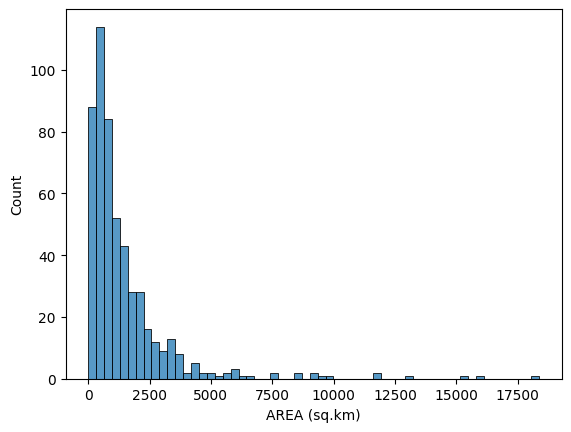

In [11]:
#Hist Plot
sns.histplot(df,x='AREA (sq.km)')

<Axes: ylabel='AREA (sq.km)'>

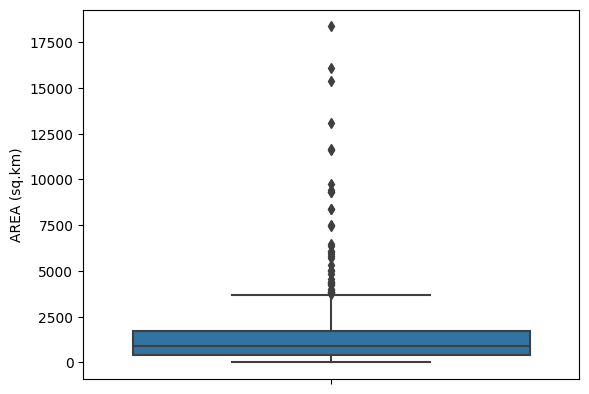

In [12]:
sns.boxplot(df,y='AREA (sq.km)')

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='ALL SEXES (RURAL)', ylabel='Count'>

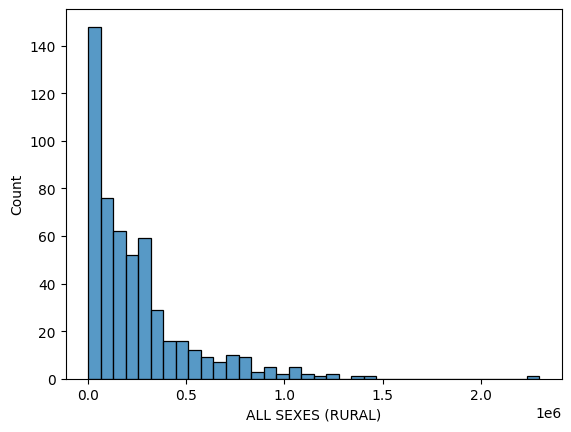

In [13]:
sns.histplot(df,x='ALL SEXES (RURAL)')

In [14]:
df['DISTRICT'].nunique()

131

In [15]:
df.groupby('DIVISION').size().sort_values()

DIVISION
Badin Division                   5
MARDAN DIVISION                  7
SAHIWAL DIVISION                 7
KOHAT DIVISION                  14
MULTAN DIVISION                 14
D.G.KHAN DIVISION               14
HAZARA DIVISION                 15
BAHAWALPUR DIVISION             15
DERA ISMAIL KHAN DIVISION       15
BANNU DIVISION                  15
Shaheed Benazirabad Division    15
SARGODHA DIVISION               17
FAISALABAD DIVISION             17
LAHORE DIVISION                 17
Kalat Division                  18
Sukkur Division                 18
PESHAWAR DIVISION               18
Mirpurkhas Division             18
Naseerabad Division             19
Zhob Division                   19
GUJRANWALA DIVISION             20
Larkana Division                21
RAWALPINDI DIVISION             22
Karachi Division                30
Hyderabad Division              30
MALAKAND DIVISION               33
Makran Division                 37
Quetta Division                 38
dtype: int6

In [16]:
df.groupby('DIVISION')['ALL SEXES (RURAL)'].mean()

DIVISION
BAHAWALPUR DIVISION             575317.533333
BANNU DIVISION                  167286.866667
Badin Division                  282922.800000
D.G.KHAN DIVISION               614505.142857
DERA ISMAIL KHAN DIVISION       156810.200000
FAISALABAD DIVISION             526807.764706
GUJRANWALA DIVISION             510698.200000
HAZARA DIVISION                 316744.800000
Hyderabad Division              176117.800000
KOHAT DIVISION                  179610.571429
Kalat Division                   60748.777778
Karachi Division                 38016.400000
LAHORE DIVISION                 348967.882353
Larkana Division                201900.333333
MALAKAND DIVISION               253212.515152
MARDAN DIVISION                 468955.714286
MULTAN DIVISION                 632220.785714
Makran Division                  42605.432432
Mirpurkhas Division             189710.722222
Naseerabad Division              70283.578947
PESHAWAR DIVISION               317484.111111
Quetta Division          

In [17]:
df.groupby(['DIVISION','DISTRICT'])['ALL SEXES (RURAL)'].mean()

DIVISION                      DISTRICT                    
BAHAWALPUR DIVISION           BAHAWALNAGAR DISTRICT           4.711940e+05
                              BAHAWALPUR DISTRICT             4.161690e+05
                              RAHIM YAR KHAN DISTRICT         9.441948e+05
BANNU DIVISION                BANNU DISTRICT                  5.585615e+05
                              FR BANNU DISTRICT               4.311200e+04
                              FR LAKKI MARWAT DISTRICT        2.639400e+04
                              LAKKI MARWAT DISTRICT           3.932460e+05
                              NORTH WAZIRISTAN DISTRICT       5.957578e+04
Badin Division                BADIN DISTRICT                  2.829228e+05
D.G.KHAN DIVISION             DERA GHAZI KHAN DISTRICT        5.816025e+05
                              LAYYAH DISTRICT                 4.938905e+05
                              MUZAFFARGARH DISTRICT           9.075345e+05
                              RAJANPUR DI

In [18]:
df.groupby(['PROVINCE','DIVISION','DISTRICT','SUB DIVISION'])['ALL SEXES (RURAL)'].mean()

PROVINCE     DIVISION                      DISTRICT                      SUB DIVISION               
BALOCHISTAN  Kalat Division                KALAT DISTRICT                GAZG SUB-TEHSIL                   5721.0
                                                                         JOHAN SUB-TEHSIL                 10708.0
                                                                         KALAT TEHSIL                     92298.0
                                                                         MANGOCHAR TEHSIL                 65678.0
                                                                         SURAB TEHSIL                    165260.0
                                           KHUZDAR DISTRICT              ARANJI SUB-TEHSIL                42318.0
                                                                         KARAKH SUB-TEHSIL                31016.0
                                                                         KHUZDAR TEHSIL              

In [19]:
print('The Total Rural Population Of Pakistan in 2017 was :',df['ALL SEXES (RURAL)'].sum())

The Total Rural Population Of Pakistan in 2017 was : 130034790


In [20]:
print('The Total Rural Population Of Pakistan in 1998 was :',df['POPULATION 1998 (RURAL)'].sum())

The Total Rural Population Of Pakistan in 1998 was : 88401981


In [21]:
# How much Rural Population increased From 1998-2017 in Rural areas
pop_rural_1998=df['POPULATION 1998 (RURAL)'].sum()
pop_rural_2017=df['ALL SEXES (RURAL)'].sum()
pop_changed=pop_rural_2017-pop_rural_1998
per_pop_changed=(pop_rural_2017/pop_rural_1998)*100
pop_changed
per_pop_changed

147.09488240993153

In [22]:
print('Increased Population in Rural Area of Pakistan',pop_changed)
print("The Persentage of Changing Population in Rural Area : ",per_pop_changed)

Increased Population in Rural Area of Pakistan 41632809
The Persentage of Changing Population in Rural Area :  147.09488240993153


In [23]:
# How much Rural Population increased From 1998-2017 in Urban areas
pop_urban_1998=df['POPULATION 1998 (URBAN)'].sum()
pop_urban_2017=df['ALL SEXES (URBAN)'].sum()
pop_changed_urban=pop_urban_2017-pop_urban_1998
per_pop_changed_urban=(pop_urban_2017/pop_urban_1998)*100
pop_changed_urban
per_pop_changed_urban

175.7617951329476

In [24]:
print('Increased Population in Urban Area of Pakistan',pop_changed_urban)
print("The Persentage of Changing Population in URban Area : ",per_pop_changed_urban)

Increased Population in Urban Area of Pakistan 32059612
The Persentage of Changing Population in URban Area :  175.7617951329476


In [25]:
# Combine male, female, transgender columns into one
df_sex = df.melt(
    id_vars=['PROVINCE', 'DIVISION', 'DISTRICT', 'SUB DIVISION'], 
    value_vars=['MALE (RURAL)', 'FEMALE (RURAL)', 'TRANSGENDER (RURAL)'],
    var_name='Sex',
    value_name='Population'
)   

df_sex.groupby(['PROVINCE', 'DIVISION', 'DISTRICT', 'SUB DIVISION', 'Sex'])['Population'].sum()

PROVINCE     DIVISION                      DISTRICT                      SUB DIVISION                 Sex                
BALOCHISTAN  Kalat Division                KALAT DISTRICT                GAZG SUB-TEHSIL              FEMALE (RURAL)            2609
                                                                                                      MALE (RURAL)              3112
                                                                                                      TRANSGENDER (RURAL)          0
                                                                         JOHAN SUB-TEHSIL             FEMALE (RURAL)            5083
                                                                                                      MALE (RURAL)              5625
                                                                                                      TRANSGENDER (RURAL)          0
                                                                         KALAT T

In [26]:
df_sex.head()

,PROVINCE,DIVISION,DISTRICT,SUB DIVISION,Sex,Population
0,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,BAHAWALNAGAR TEHSIL,MALE (RURAL),316864
1,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,CHISHTIAN TEHSIL,MALE (RURAL),273788
2,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,FORT ABBAS TEHSIL,MALE (RURAL),182655
3,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,HAROONABAD TEHSIL,MALE (RURAL),192278
4,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,MINCHINABAD TEHSIL,MALE (RURAL),231506


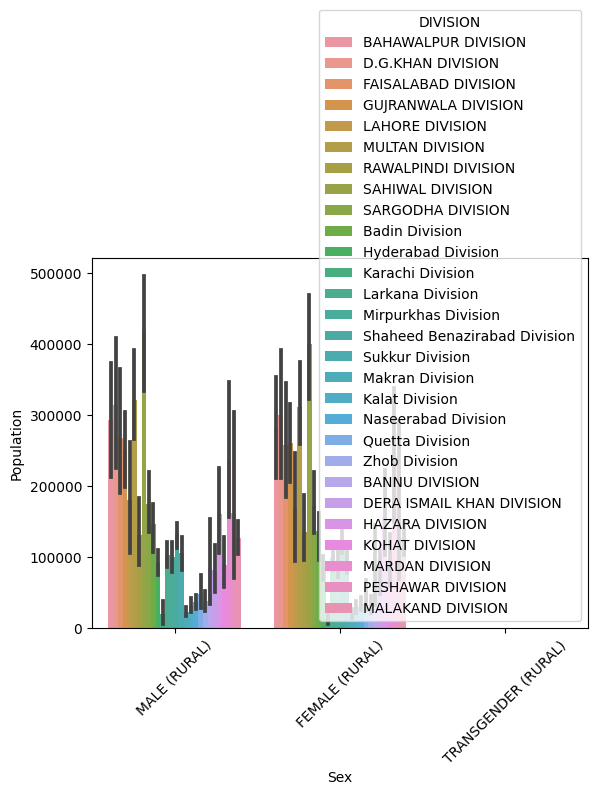

In [27]:
sns.barplot(data=df_sex, x='Sex', y='Population', hue='DIVISION')
plt.xticks(rotation=45)
plt.show()